In [2]:
import pandas as pd
import cobra
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib import font_manager
from matplotlib_venn import venn3
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm
import sys
sys.path.append('../')
from modelfunctions import *

# use Arial
try: 
    font_path = '/home/emil/.fonts/ARIAL.TTF'  # Your font path goes here
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except:
    print('Arial font not found, using default')

wd = os.path.abspath(os.getcwd()).removesuffix('Code/cyanoCompare')
figdir = wd + 'Figures/'
cyadir = wd + 'Data/analysis/cyanoCompare/'

cols_opt_order = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70),
 (0xee, 0x96, 0x4b), (0x0, 0x6d, 0x6f), (0xb6, 0xd0, 0x94), (0xe5, 0x62, 0x5e),
 (0xff, 0xbf, 0xa0), (0x66, 0x0, 0x0), (0xab, 0x81, 0xcd), (0x29, 0x70, 0x45),
 (0xba, 0xde, 0xfc)]]
figsize = (4, 3)

In [3]:
# import all of the models
import_version = 1

with silence():
    pcm = cobra.io.read_sbml_model(f'{wd}Data/pcm/species/Arabidopsis_thaliana.pcm.v{import_version + 1}.xml')
    apc = cobra.io.read_sbml_model(f'{wd}Data/pcm/pluggedIntoAraCore/AraCore.Arabidopsis_thaliana.pcm.xml')
    cyano = cobra.io.read_sbml_model(f'{cyadir}cyano_light_fixed.xml')
    acy = cobra.io.read_sbml_model(f'{cyadir}aracore.cyano.xml')
    ara = cobra.io.read_sbml_model(f'{wd}Data/comparison_models/AraCore_v2_1.wKEGG.xml')

## Post-processing of ACY
The idea is to pretend as if the cyanobacterium was a chloroplast

In [4]:
# some curation is necessary:
# Growth not initially possible, maltose only degradable, not producible. To be able to simulate growth, set MALT reversible
get_rid(acy, 'MALT').lower_bound = -1000 
# and add a reaction to be able to produce maltose from glycogen
r = cobra.Reaction('Glyc_mal_h', 'breakup of glycogen to maltose', lower_bound = 0, upper_bound = 1000)
r.add_metabolites({get_mid(acy, 'glycogen_h[h]'): -2, get_mid(acy, 'Mas[h]'): 1, get_mid(acy, 'H2O[h]'): 1})
acy.add_reactions([r])
    
# add photorespiration constraint 
# add PHOTO_c metabolite to the model
m = cobra.Metabolite('CONST_rubisco[x]', compartment='x', name='Photorespiration pseudo-metabolite')
acy.add_metabolites([m])

# the ratio is set to 30:1 in favor of carboxylation (around 3%, as per the Joshi et al paper)
get_rid(acy, 'RBPC').add_metabolites({'CONST_rubisco[x]': 1})
get_rid(acy, 'RBCh').add_metabolites({'CONST_rubisco[x]': -30})

# add glycogen exchange to simulate usage of storage compounds in the night (blocked for now)
r = cobra.Reaction('EX_glycogen_e', 'Glycogen exchange', lower_bound = 0, upper_bound = 0)
r.add_metabolites({get_mid(acy, 'glycogen_h[h]'): -1})
acy.add_reactions([r])

# add starch2 exchange to apc to simulate usage of storage compounds in the night (blocked for now)
r = cobra.Reaction('Im_starch2', 'Starch exchange', lower_bound = 0, upper_bound = 0)
r.add_metabolites({get_mid(acy, 'starch2[h]'): 1})
apc.add_reactions([r])

# remove this reaction from the cyanobacterium model: is empty anyways
acy.remove_reactions(['Sink_dna'])

# Add a water sink to the cyanobacterial model since this leads to much reduced ATP production rates 
r = cobra.Reaction('Sk_h2o_h')
r.add_metabolites({get_mid(acy, 'H2O[h]'): -1})
acy.add_reactions([r])

### Set night and day conditions

In [5]:
# cyanobacterium model
bm_rid = 'Bio_opt'

day_acy = acy.copy()
# For each exchange and import reaction, if the metabolite contains carbon, set to 0
for r in day_acy.reactions:
    # the ones involving more than one metabolite have been reviewed and involve uptake of P, N, S
    if ('ex_' in r.id.lower() or 'im_' in r.id.lower()) and len(r.metabolites) == 1:
        for m in r.metabolites:
            if m.formula is not None and 'C' in m.formula:
                r.lower_bound = 0
# This has to be set manually as they involve carbon but are not caught by the above
get_rid(day_acy, 'EX_glycogen_e').lower_bound = 0

# set light uptake to 1000 and co2 uptake to 3.7 # No; see apc generatiion for explanation
get_rid(day_acy, 'Im_hnu').upper_bound = 1000
get_rid(day_acy, 'Im_CO2').upper_bound = 1000

# measure amount of glycogen producible per hour
sol = day_acy.optimize()
glycogen_storage = sol.fluxes[bm_rid] * get_rid(day_acy, bm_rid).metabolites[get_mid(day_acy, 'glycogen_h[h]')]

# generate night model
night_acy = day_acy.copy()

# Set glycogen exchange to consume glycogen at the same rate as it was generated during the day
# set glycogen exchange to a value s.th. biomass prodcution is around the same as during the day
# starch/glycogen uptake has to be the same across cyano and chloro model since biomass scales exaclty the same and dependent on starch import  
get_rid(night_acy, 'EX_glycogen_e').lower_bound = -16 #float(glycogen_storage)
# set light and CO2 uptake to 0
get_rid(night_acy, 'Im_hnu').upper_bound = 0
get_rid(night_acy, 'Im_CO2').upper_bound = 0
get_rid(night_acy, 'Ex_O2').lower_bound = -1000
night_acy.repair()

# Output to disk
cobra.io.write_sbml_model(day_acy, f'{cyadir}coupling_models/day_acy.xml')
cobra.io.write_sbml_model(night_acy, f'{cyadir}coupling_models/night_acy.xml')
print('Amount of glycogen producible per hour during the day is', glycogen_storage)

Read LP format model from file /tmp/tmp0dqlcer4.lp
Reading time = 0.00 seconds
: 1167 rows, 2824 columns, 12686 nonzeros
Read LP format model from file /tmp/tmpv2knpd69.lp
Reading time = 0.00 seconds
: 1167 rows, 2824 columns, 12686 nonzeros
Amount of glycogen producible per hour during the day is -2.870587908228367


In [6]:
# c3 chloroplast model
bm_rid = 'Bio_opt'

day_apc = apc.copy()
# For each exchange and import reaction, if the metabolite contains carbon, set to 0
for r in day_apc.reactions:
    # the ones involving more than one metabolite have been reviewed and involve uptake of P, N, S
    if ('ex_' in r.id.lower() or 'im_' in r.id.lower()) and len(r.metabolites) == 1:
        for m in r.metabolites:
            if m.formula is not None and 'C' in m.formula:
                r.lower_bound = 0
# These have to be set manually as they involve carbon but are not caught by the above
get_rid(day_apc, 'Im_suc').upper_bound = 0
get_rid(day_apc, 'Im_str').upper_bound = 0

# set light uptake to 1000 and co2 uptake to 3.7: this leads to photorespiration becoming irrelevant
#   because there is enough energy to offset it. Following the paper and constraining the
#   light uptake to the minimum amount required at carbon limiting conditions leads to photorespiration
#   becoming irrelevant at ratios superior to the realistic ones 
# Just use 1000 and 1000?
get_rid(day_apc, 'Im_CO2').upper_bound = 1000
get_rid(day_apc, 'Im_hnu').upper_bound = 1000#day_apc.optimize().fluxes.loc['Im_hnu']

# measure amount of starch producible per hour
sol = day_apc.optimize()
starch_storage = sol.fluxes[bm_rid] * get_rid(day_apc, bm_rid).metabolites[get_mid(day_apc, 'starch2[h]')]

# generate night model
night_apc = day_apc.copy()

# Set starch exchange to consume starch at the same rate as it was generated during the day
get_rid(night_apc, 'Im_starch2').upper_bound = 8 #- float(starch_storage)
# set light and CO2 uptake to 0, and oxygen uptake to 1000
get_rid(night_apc, 'Im_hnu').upper_bound = 0
get_rid(night_apc, 'Im_CO2').upper_bound = 0
get_rid(night_apc, 'Ex_O2').lower_bound = -1000

# Output to disk
cobra.io.write_sbml_model(day_apc, f'{cyadir}coupling_models/day_apc.xml')
cobra.io.write_sbml_model(night_apc, f'{cyadir}coupling_models/night_apc.xml')

Read LP format model from file /tmp/tmp_jndguy3.lp
Reading time = 0.00 seconds
: 1534 rows, 4002 columns, 17156 nonzeros
Read LP format model from file /tmp/tmpl6fizpyf.lp
Reading time = 0.01 seconds
: 1534 rows, 4002 columns, 17156 nonzeros


In [7]:
# generate a night AraCore model, used in coupling analysis to complement the other models
night_ara = ara.copy()
get_rid(night_ara, 'Im_hnu').upper_bound = 0
get_rid(night_ara, 'Im_CO2').upper_bound = 0
get_rid(night_ara, 'Ex_O2').lower_bound = -1000
imp_rxn = cobra.Reaction('Im_starch', lower_bound=0, upper_bound=8)
imp_rxn.add_metabolites({get_mid(night_ara, 'starch2[h]'): 1})
night_ara.add_reactions([imp_rxn])

Read LP format model from file /tmp/tmp3li6dn26.lp
Reading time = 0.00 seconds
: 415 rows, 1170 columns, 4402 nonzeros


In [8]:
print("Cyanobacterium growth under light:", day_acy.slim_optimize())
print("Cyanobacterium growth in the dark:", night_acy.slim_optimize())
print("Chloroplast growth under light:", day_apc.slim_optimize())
print("Chloroplast growth in the dark:", night_apc.slim_optimize())

Cyanobacterium growth under light: 0.0027743786249703954
Cyanobacterium growth in the dark: 0.002653408482269739
Chloroplast growth under light: 0.002407471542206912
Chloroplast growth in the dark: 0.0026534084822697358


### Gather data for the comparison of transporters

In [9]:
# get list of transporter reaction IDs
# pcm aracore model
pcm_comps = list(pcm.compartments.keys())
pcm_comps.remove('c')

cp_trs = set()
for r in day_apc.reactions:
    if 'Bio' in r.id:
        continue
    comps = {m.compartment for m in r.metabolites}
    if comps.intersection(pcm_comps) and comps.difference(pcm_comps):
            cp_trs.add(r.id)

# cyanobacteria aracore model
cyano_comps = list(cyano.compartments.keys())
cyano_comps.remove('c')
cyano_comps.append('h')
cyano_comps.remove('p')
cyano_comps.append('z')
cyano_comps.remove('e')

cya_trs = set()
for r in day_acy.reactions:
    if 'Bio' in r.id:
        continue
    comps = {m.compartment for m in r.metabolites}
    if comps.intersection(cyano_comps) and comps.difference(cyano_comps):
            cya_trs.add(r.id)

# aracore model
chl_comps = ['h', 'l']

ara_trs = set()
for r in ara.reactions:
    if 'Bio' in r.id:
        continue
    comps = {m.compartment for m in r.metabolites}
    if comps.intersection(pcm_comps) and comps.difference(pcm_comps):
        ara_trs.add(r.id)

# get list of reactions outside of the chloroplast
out_cp, out_cy = set(), set()
for r in day_apc.reactions:
    comps = {m.compartment for m in r.metabolites}
    if not comps.intersection(pcm_comps):
        out_cp.add(r.id)
for r in day_acy.reactions:
    comps = {m.compartment for m in r.metabolites}
    if not comps.intersection(cyano_comps):
        out_cy.add(r.id)

ara_excl = out_cp.intersection(out_cy)
non_cp_cp = out_cp.difference(out_cy)
non_cp_cy = out_cy.difference(out_cp)

In [10]:
# Try to map some of the transporters
print_half_matches = False
print_tr_mapping = False
mapping_d_pcm = {cpt: [m.id for m in get_rid(apc, cpt).metabolites
                           if m.compartment == 'c' and m.id not in ['H[c]', 'H2O[c]']]
                 for cpt in cp_trs}

mapping_d_cya = {cyt: [m.id for m in get_rid(acy, cyt).metabolites
                           if m.compartment == 'c' and m.id not in ['H[c]', 'H2O[c]']]
                 for cyt in cya_trs}

# tr_mapping maps from apc to acy
tr_mapping = {}
count = 0
for cpt in mapping_d_pcm:
    any_found = False
    if cpt in mapping_d_cya:
        tr_mapping[cpt] = [cpt]
        any_found = True
    else:
        to_print = []
        for cyt in mapping_d_cya:
            if mapping_d_pcm[cpt] == mapping_d_cya[cyt]:
                tr_mapping[cpt] = tr_mapping.get(cpt, []) + [cyt]
                any_found = True
            elif set(mapping_d_pcm[cpt]).intersection(mapping_d_cya[cyt]).difference(['H[c]', 'H2O[c]']):
                to_print.append(cyt)
        if not any_found and to_print and print_half_matches:
            print(f'*{cpt}: {sorted(mapping_d_pcm[cpt])}')
            for cyt in to_print:
                print(f'.{cyt}: {sorted(mapping_d_cya[cyt])}')
            print()
    
    if not any_found:
        count += 1

if print_tr_mapping:
    for cpt in tr_mapping:
        if len(tr_mapping[cpt]) > 1 or tr_mapping[cpt][0] != cpt:
            print(f'*{get_rid(apc, cpt)}')
            for cyt in tr_mapping[cpt]:
                print(f'.{get_rid(acy, cyt)}')
            print()

# Do some manual curation of mappings
tr_mapping['Tr_Pyr_H_hc'] = ['Tr_Pyr_H_h']
tr_mapping['Tr_Pi'] = ['Im_Pi']
_ = tr_mapping.pop('Tr_H')

for k, v in tr_mapping.items():
    if type(v) == list:
        if len(v) > 1:
            print(k, v)
        else:
            tr_mapping[k] = v[0]

### Comparison of model stats

In [11]:
# check the number of active reactions of the different models
x_apc = cobra.flux_analysis.flux_variability_analysis(day_apc)
num_active_apc = x_apc.loc[~((x_apc['minimum'].abs() < 1e-8) & (x_apc['maximum'].abs() < 1e-8))].shape[0]
print('APC:', num_active_apc)
x_acy = cobra.flux_analysis.flux_variability_analysis(day_acy)
num_active_acy = x_acy.loc[~((x_acy['minimum'].abs() < 1e-8) & (x_acy['maximum'].abs() < 1e-8))].shape[0]
print('ACY:', num_active_acy)
x_acy = cobra.flux_analysis.flux_variability_analysis(cyano)
num_active_cyano = x_acy.loc[~((x_acy['minimum'].abs() < 1e-8) & (x_acy['maximum'].abs() < 1e-8))].shape[0]
print('iSynCJ816:', num_active_cyano)
x_acy = cobra.flux_analysis.flux_variability_analysis(pcm)
num_active_pcm = x_acy.loc[~((x_acy['minimum'].abs() < 1e-8) & (x_acy['maximum'].abs() < 1e-8))].shape[0]
print('PCM:', num_active_pcm)
active_d = {'APC': num_active_apc, 'ACY': num_active_acy, 'iSynCJ816': num_active_cyano, 'PCM': num_active_pcm}

APC: 653
ACY: 552
iSynCJ816: 790
PCM: 725


iSynCJ816 790
PCM 725
ACY 552
APC 653


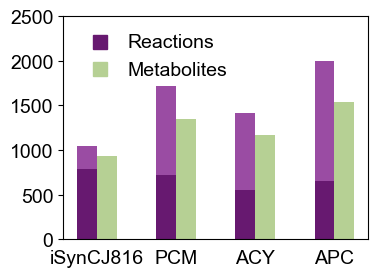

In [12]:
# plot the sizes of the different models
snd_col_idx = 3
xlab_rotation = 0
figname = 'cyano_stats_comp'
plt.rcParams['font.size'] = 14
col_diff = 0.2

plt.figure(figsize=figsize)
colname_dict = {'nRxns': 'Reactions', 'nMets': 'Metabolites'}#, 'nSubsystems': 'Subsystems'}
def get_gem_stats(model):
    return {'nRxns': len(model.reactions), 'nMets': len(model.metabolites)}#, 'nSubsystems': len(model.groups)}

stats = pd.DataFrame({'iSynCJ816': get_gem_stats(cyano), 'PCM': get_gem_stats(pcm),
         'ACY': get_gem_stats(day_acy), 'APC': get_gem_stats(day_apc)}).T

# Left plot
data = stats
barWidth = 0.25
betweenBarWidth = 1
r1 = np.arange(data.shape[0])
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]
rs = [r1, r2, r3, r4]


r1 = np.arange(0, barWidth * 2, step=barWidth)
r2 = [x + betweenBarWidth for x in r1]
r3 = [x + betweenBarWidth for x in r2]
r4 = [x + betweenBarWidth for x in r3]
rs = [r1, r2, r3, r4]

# bars
colors_used, labels = [], []
main_cols = [cols_opt_order[0], cols_opt_order[snd_col_idx]]
for i, idx in enumerate(data.index):
    curr_cols = [[min(1, cv + col_diff) for cv in main_cols[0]], main_cols[1]]
    plt.bar(rs[i], data.loc[idx], barWidth, color = curr_cols)
    plt.bar(rs[i][0], active_d[idx], barWidth, color = main_cols[0])
    print(idx, active_d[idx])
        

# Add tick labels and titles
#plt.xticks([r + (barWidth * (data.shape[1] - 1) / 2) for r in r1], 
plt.xticks([np.mean(r) for r in rs], 
        labels = data.index, rotation=xlab_rotation, va = 'top', ha="center" if xlab_rotation <= 20 else "right")
plt.tick_params(bottom = False)
yticks = [500 * i for i in range(6)]
plt.yticks(yticks, yticks)

# legend
plt.legend(frameon=False, 
           handles = [mpl.lines.Line2D([], [], marker = 's', linewidth=0, markersize = 10,
                                       color=main_cols[i])
                                       for i in range(len(main_cols))],
           labels=['Reactions', 'Metabolites'],
           handletextpad = 0.4, handleheight = 0.4, ncols = 1, loc='upper left')
#plt.ylim(plt.ylim()[0], plt.ylim()[1]*1.2)

if figname is not None:
    plt.tight_layout()
    plt.savefig(f'{figdir}{figname}.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

## Perform analyses with the transporters made equal
The transporter unique to AraCore is Tr_DHO1, which is the dihydroorotate-related one that I had removed manually. The one shared by the two plastid models but not in AraCore is the transporter of the precursor that I added manually.

The results generated for the models without the transporters being made equal are not shown but will be made available upon request

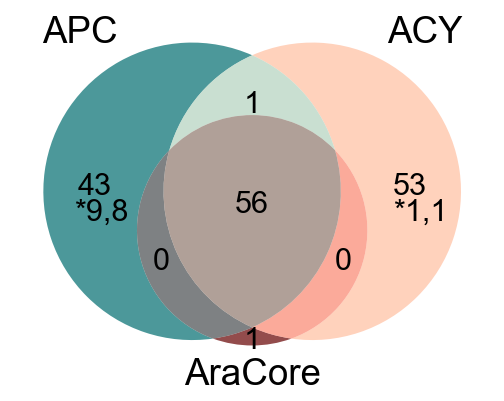

Marked with an asterisk are the number of transporters that are active in day and night conditions


In [13]:
# generate plot comparing the sets of transporters
# with matching of transporters, and numbers for how many of the exclusive transporters are active
# the numbers are hard-coded here because their inferral used large amounts of flux sampling data
#   that is made available upon request. It was generated using CobraPy for the ACY and APC model
#   with the set of transporters not changed
apc_color = cols_opt_order[2]
acy_color = cols_opt_order[5]
plt.rcParams['font.size'] = 22

translated_apc_trs = {tr_mapping[cpt] if cpt in tr_mapping else cpt + 'pcm' for cpt in cp_trs}
venn_plt = venn3((translated_apc_trs, cya_trs, ara_trs), set_labels=['APC', 'ACY', 'AraCore'],
                 set_colors=[apc_color, acy_color, cols_opt_order[6]],
      alpha = 0.7, layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(50,50,0,10,0,0,50)))
for t in venn_plt.subset_labels:
    x, y = t.get_position()
    if t.get_text() == '43':  # APC
        plt.text(x - 0.06, y - 0.1, f'*9,8')
    if t.get_text() == '53':  # ACY
        plt.text(x - 0.05, y - 0.1, f'*1,1')
        
plt.savefig(f'{figdir}cyano_transporter_venn.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()
plt.rcParams['font.size'] = 16
print('Marked with an asterisk are the number of transporters that are active in day and night conditions')

### Make transporters equal using intersection of transporters

In [14]:
# gather lists of transporter reactions to be able to determine intersection and make the sets equal
translated_apc_trs = {tr_mapping[cpt] if cpt in tr_mapping else cpt + 'pcm' for cpt in cp_trs}
acy_exclusive_trs = list(cya_trs.difference(translated_apc_trs))
cp_trs_excl = {cp for cp in cp_trs if cp not in tr_mapping or tr_mapping[cp] not in cya_trs}
tr_inters_cy = {tr_mapping[cp] for cp in cp_trs
                    if cp in tr_mapping and tr_mapping[cp] in cya_trs}
tr_inters_pc = {cp for cp in cp_trs
                if cp in tr_mapping and tr_mapping[cp] in cya_trs}

In [15]:
# generate the models with the set of transporters made equal
def get_inters_version(model, apc_model = False):
    model_trin = model.copy()

    if apc_model:
        excl_trs = cp_trs_excl.copy()
    else:
        excl_trs = acy_exclusive_trs.copy()

    pr_nogr, pr_inf = False, False
    # knock out the exclusive transporters
    for rid in excl_trs:
        get_rid(model_trin, rid).knock_out()
        res = model_trin.slim_optimize()
        if res != res and not pr_inf:
            print('Infeas', rid)
            pr_inf = True
        if res <= 1e-8 and not pr_inf and not pr_nogr:
            print('No gr', rid)
            pr_nogr = True

    if apc_model:
        # for apc, knock out the version of each transporter that has different directionality than the one in acy.
        # We should be able to just only use the one that has the same name between both models (from AraCore)
        addit_ko = tr_inters_pc.difference(tr_inters_cy).copy()
        actually_transl_trs = translated_apc_trs.intersection(tr_inters_cy).difference(tr_inters_pc.intersection(tr_inters_cy))
        for x in tr_mapping:
            if tr_mapping[x] in actually_transl_trs:
                addit_ko.remove(x)
        addit_ko = list(addit_ko)
        for rid in addit_ko:
            get_rid(model_trin, rid).knock_out()
            res = model_trin.slim_optimize()
            if res != res and not pr_inf:
                print('Infeas', rid)
                pr_inf = True
            if res <= 1e-8 and not pr_inf and not pr_nogr:
                print('No gr', rid)
                pr_nogr = True
    
    return model_trin

day_apc_trin = get_inters_version(day_apc, apc_model=True)
night_apc_trin = get_inters_version(night_apc, apc_model=True)
day_acy_trin = get_inters_version(day_acy)
night_acy_trin = get_inters_version(night_acy)

Read LP format model from file /tmp/tmpwx7jpvs_.lp
Reading time = 0.01 seconds
: 1534 rows, 4002 columns, 17156 nonzeros
Read LP format model from file /tmp/tmpbm2vurig.lp
Reading time = 0.00 seconds
: 1534 rows, 4002 columns, 17156 nonzeros
Read LP format model from file /tmp/tmp5qrlsj3w.lp
Reading time = 0.00 seconds
: 1167 rows, 2824 columns, 12686 nonzeros
Read LP format model from file /tmp/tmp941vnc60.lp
Reading time = 0.00 seconds
: 1167 rows, 2824 columns, 12686 nonzeros


### Photorespiration analysis

In [16]:
def photoresp_plot(xs, res_chloro, res_acy, c3_realistic_ratio=3, cyano_ratio=33, savename = None,
                   figsize=(4, 3), num_yticks = 3):

    plt.figure(figsize=figsize)

    cyano_idx = np.argmin(np.abs(xs - cyano_ratio))
    plt.plot([1/(x + 1) for x in xs], res_chloro, c=apc_color, label='APC')
    plt.plot([1/(c3_realistic_ratio + 1)], res_chloro[np.where(xs == c3_realistic_ratio)[0][0]],
            '--o', c=apc_color)

    plt.plot([1/(x + 1) for x in xs], res_acy, c=acy_color, label='ACY')
    plt.plot([1/(cyano_ratio + 1)], res_acy[cyano_idx],
            '--o', c=acy_color)

    plt.xlabel('RuBisCO O:CO ratio')
    plt.ylabel(r'Pred. max growth rate $\left[\text{h}^{-1}\right]$')

    xlim = plt.xlim()
    ylim = plt.ylim()

    # also add dashed line to the axes to indicate the values
    c3x = 1/(c3_realistic_ratio + 1)
    c3y = res_chloro[np.where(xs == c3_realistic_ratio)[0][0]]
    cyanox = 1/(cyano_ratio + 1)
    cyanoy = res_acy[cyano_idx]
    plt.hlines(c3y, xlim[0], c3x, color=apc_color, ls='--')
    plt.hlines(cyanoy, xlim[0], cyanox, color=acy_color, ls='--')

    plt.vlines(c3x, ylim[0], c3y, color=apc_color, ls='--')
    plt.vlines(cyanox, ylim[0], cyanoy, color=acy_color, ls='--')
    plt.xlim(xlim)
    plt.ylim(ylim)

    # axis ticks
    curr_tickvals = plt.yticks()[0]
    magn = 0
    while not all(round(val) == val for val in curr_tickvals):
        curr_tickvals = [val * 10 for val in curr_tickvals]
        magn += 1
    def ytick_formatting(x, pos):
        return str(int(x * (10**magn)))
    xticks = [i/10 for i in range(7)]
    plt.xticks(xticks, xticks)

    if savename is not None:
        plt.savefig(f'{figdir}{savename}.png', dpi=300, transparent=True, bbox_inches='tight')
    plt.show()

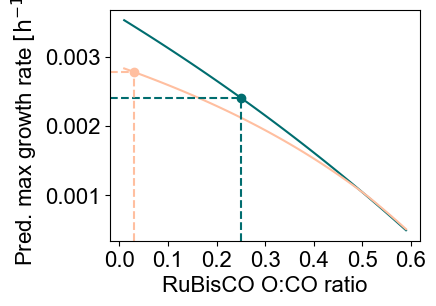

In [17]:
# Check dependence of growth on photorespiration
xs = np.apply_along_axis(lambda y: 1/y - 1, 0, np.arange(0.01, 0.6, 0.01))

const_m = get_mid(day_apc_trin, 'CONST_rubisco[h]')
c3_realistic_ratio = 3
res_chloro = []
for ratio in xs:
    get_rid(day_apc_trin, 'RBO_h').add_metabolites({const_m: -get_rid(day_apc_trin, 'RBO_h').metabolites[const_m] - ratio})
    res_chloro.append(day_apc_trin.slim_optimize())
# reset value
get_rid(day_apc_trin, 'RBO_h').add_metabolites({const_m: -get_rid(day_apc_trin, 'RBO_h').metabolites[const_m] - c3_realistic_ratio})

# simulate for cyanobacterium
cyano_ratio = 33
# find element of xs that is closest to cyano_ratio
const_m = get_mid(day_acy_trin, 'CONST_rubisco[x]')
res_acy = []
for ratio in xs:
    get_rid(day_acy_trin, 'RBCh').add_metabolites({const_m: -get_rid(day_acy_trin, 'RBCh').metabolites[const_m] - ratio})
    res_acy.append(day_acy_trin.slim_optimize())
# reset value
get_rid(day_acy_trin, 'RBCh').add_metabolites({const_m: -get_rid(day_acy_trin, 'RBCh').metabolites[const_m] - cyano_ratio})

photoresp_plot(xs, res_chloro, res_acy, figsize=(4,3), savename='cyano_pcm_photoresp')

### Flux coupling analysis

In [18]:
# write out the models for use with F2C2 in matlab
cobra.io.write_sbml_model(day_apc_trin, f'{cyadir}coupling_models/day_apc_trin.xml')
cobra.io.write_sbml_model(night_apc_trin, f'{cyadir}coupling_models/night_apc_trin.xml')
cobra.io.write_sbml_model(day_acy_trin, f'{cyadir}coupling_models/day_acy_trin.xml')
cobra.io.write_sbml_model(night_acy_trin, f'{cyadir}coupling_models/night_acy_trin.xml')

Run matlab script analysis/cyanoCouplingAnalysis.m

In [20]:
# read results
# all chl reactions
# distribution of number of cyt rxns that are coupled with a certain type to the different chl reactions
chl_comps = {'dayApc_trin': ['h', 'l', 'ohm', 'hm', 'pg'],
             'nightApc_trin': ['h', 'l', 'ohm', 'hm', 'pg'],
             'dayAcy_trin': ['h', 'x', 'z', 'y', 'u', 'l'],
             'nightAcy_trin': ['h', 'x', 'z', 'y', 'u', 'l'],
             'AraCore': ['h', 'l'],
             'nightAraCore': ['h', 'l']}
models = {'AraCore': ara, 'dayApc_trin': day_apc_trin, 'dayAcy_trin': day_acy_trin,
            'nightApc_trin': night_apc_trin, 'nightAcy_trin': night_acy_trin,
            'nightAraCore': night_ara}
non_chl_rids = [r.id for r in ara.reactions if not any(m.compartment in chl_comps['AraCore'] for m in r.metabolites)]

res = {}
for i, model_name in enumerate(models):
    df = pd.read_csv(f'{cyadir}coupling_results/{model_name}.csv', index_col = 0)

    # check coupling of all non-blocked reactions of chloroplast to rest of the cell
    # get chl reaction set
    chl_rids = [r.id for r in models[model_name].reactions if all(m.compartment in chl_comps[model_name] for m in r.metabolites)]
    chl_rids = df.index.intersection(chl_rids) # blocked reactions
    curr_non_chl_rids = df.columns.intersection(non_chl_rids)

    # subset to the couplings of chloroplast to non-chloroplast reactions
    res[model_name] = (df.loc[chl_rids, curr_non_chl_rids] \
        # count the number of the different types of couplings for each chl reaction 
        .apply(lambda s: s.value_counts(), axis=1).fillna(0).astype(int)
        # calculate the mean
        #.mean())
        # remove uncoupled value
        .drop(0, axis=1))
present_types = sorted(list(set.union(*[set(res[model_name].columns.to_list()) for model_name in models.keys()])))
    
for i, model_name in enumerate(models):
    for coupl_type in present_types:
        if coupl_type not in res[model_name].columns:
            res[model_name][coupl_type] = 0
        res[model_name].sort_index(axis=1)

models_order = ['dayAcy_trin', 'dayApc_trin', 'AraCore', 'nightAcy_trin', 'nightApc_trin', 'nightAraCore']

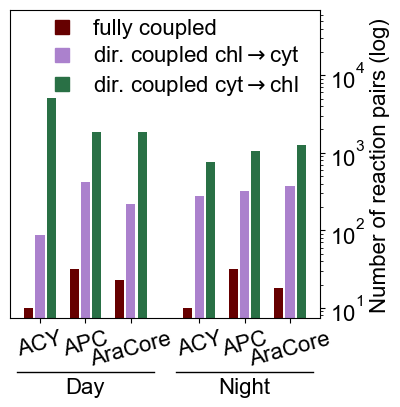

In [21]:
# number of reaction pairs that are coupled between chl and cyt comp
plt.rcParams['font.size'] = 16
fig = plt.figure(figsize = (4,4))
cols_used = cols_opt_order[6:9]

bar_mid_poss = [1.0, 5.0, 9.0, 15.0, 19.0, 23.0]
for i, model_name in enumerate(models_order):
    agg_data = res[model_name].sum()
    data = [agg_data[coupl_type] if coupl_type in agg_data.index else 0 for coupl_type in present_types]
    n_bars = len(present_types)
    poss = [i*(n_bars + 1) + j for j in range(n_bars)]
    poss = [bar_mid_poss[i] + j - ((n_bars - 1) / 2) for j in range(n_bars)]
    plt.bar(poss, data, color = cols_used)

def format_xticks(x):
    res = x.removesuffix('_trin')
    for cond in ['day', 'night']:
        if cond in res:
            res = res.replace(cond, '').upper() + f' ({cond})'
    
    if 'aracore' in res.lower():
        if 'night' in res.lower():
            return 'AraCore (night)'
        return 'AraCore (day)'
    return res

def format_xticks(x):
    res = x.removesuffix('_trin')
    for cond in ['day', 'night']:
        if cond in res:
            res = res.replace(cond, '').upper()
    
    if 'aracore' in res.lower():
        return 'AraCore'
    return res

# without day/night spacing: [(len(present_types) - 1)/2 + (n_bars + 1)*i for i in range((len(models_order)))]
plt.xticks([1.0, 5.0, 9.0, 15.0, 19.0, 23.0],
           map(format_xticks, models_order), rotation=15, ha='center')

plt.text((bar_mid_poss[0] + bar_mid_poss[len(present_types) - 1]) / 2, 
         0.8, 'Day', ha='center')
plt.text((bar_mid_poss[len(present_types)] + bar_mid_poss[-1]) / 2,
         0.8, 'Night', ha='center')

#plt.xlabel('Model')
type_translation = {0: 'uncoupled', 1:'fully coupled', 2:'partially coupled',
                    3:r'dir. coupled chl$\rightarrow$cyt',4:r'dir. coupled cyt$\rightarrow$chl'}
plt.legend(frameon=False, bbox_to_anchor = (1, 1.04),
           handles = [mpl.lines.Line2D([], [], marker = 's', linewidth=0, markersize = 10,
                                       color=cols_used[i])
                                       for i in range(len(present_types))],
           labels=[type_translation[i] for i in present_types],
           handletextpad = 0.4, handleheight = 0.4, labelspacing = 0.2,
           ncols = 1, loc='upper right')
#plt.tick_params(bottom = False)#, left = False, right = True, labelright = True, labelleft = False)
plt.yscale('log')
plt.ylim(plt.ylim()[0], plt.ylim()[1]*10)
plt.ylabel('Number of reaction pairs (log)')
plt.gca().yaxis.set_label_position("right")
plt.gca().yaxis.tick_right()


from matplotlib.lines import Line2D
line = Line2D([-1 ,bar_mid_poss[len(present_types) - 1] + 2], [1.5, 1.5], lw=1., color='k', clip_on = False)
plt.gca().add_line(line)
line = Line2D([bar_mid_poss[len(present_types)] - 2, bar_mid_poss[2 * len(present_types) - 1] + 2], [1.5, 1.5],
                lw=1., color='k', clip_on = False)
plt.gca().add_line(line)

plt.savefig(f'{figdir}num_rxn_pairs_trin.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()

In [22]:
for i, model_name in enumerate(models):
    print(model_name, (res[model_name].sum(axis=1) > 0).sum())

AraCore 127
dayApc_trin 108
dayAcy_trin 153
nightApc_trin 244
nightAcy_trin 266
nightAraCore 169
